# Spectral Analysis — Feature-Filtered L-SML with Offline-Calibrated Thresholds

**Step 121 notebook.** 2×2 ablation study:

| | Median binarization | Optimized-quantile binarization |
|---|---|---|
| **All 16 features** | V1 (current v2 reference) | V3 |
| **Filtered subset** | V2 (GOOD_FEATURES_MEDIAN) | **V4 (GOOD_FEATURES_OPT, proposed best)** |

**Each variant uses its own feature subset**, derived from the AUROC of that binarization method:
- `GOOD_FEATURES_MEDIAN`: features with mean individual AUROC ≥ threshold under **median** binarization (Cell 4)
- `GOOD_FEATURES_OPT`: features with mean individual AUROC ≥ threshold under **optimised-quantile** binarization (Cell 6)

**Two offline preprocessing steps:**
1. **Feature selection** (Cells 4 & 6): remove features with consistently low individual AUROC — they pollute the L-SML covariance matrix.
2. **Per-feature threshold calibration** (Cell 5): for each feature find the quantile q* that maximises mean individual AUROC across all historical cells; freeze it for test time.

**Why this is valid:** Both `GOOD_FEATURES_*` and `FEATURE_QUANTILES_OPT` are derived *once* from historical labelled data — same epistemological status as `FEATURE_SIGNS`. No labels are used at test time.

**CPU-only — re-uses cached feature pkls from `consolidated_results/` on Drive.**

## Section 1 — Setup

In [3]:
import os, sys, shutil

REPO_DIR = '/content/hallucination_detection'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b master https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets scipy scikit-learn matplotlib')

import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spectral_utils import (
    FEAT_NAMES, boot_auc, binarize_classifiers, lsml_fuse,
)

print('spectral_utils imported OK')
print(f'FEAT_NAMES ({len(FEAT_NAMES)}): {FEAT_NAMES}')

spectral_utils imported OK
FEAT_NAMES (16): ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx']


## Section 2 — Config & Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')

BASE     = '/content/drive/MyDrive'
HALL_DIR = f'{BASE}/hallucination_detection'
OUT_DIR  = f'{HALL_DIR}/consolidated_results'
os.makedirs(OUT_DIR, exist_ok=True)

# FEATURE_SIGNS: Step 110 consensus across 29 cells
# +1 = higher raw value -> more likely correct; -1 -> hallucination
FEATURE_SIGNS = {
    'epr': -1, 'trace_length': 1, 'spectral_entropy': -1,
    'low_band_power': -1, 'high_band_power': -1, 'hl_ratio': -1,
    'dominant_freq': -1, 'spectral_centroid': -1,
    'stft_max_high_power': -1, 'stft_spectral_entropy': -1,
    'rpdi': -1, 'sw_var_peak': -1,
    'pe_mean': -1, 'hurst_exponent': 1,
    'cusum_max': -1, 'cusum_shift_idx': 1,
}

# Adjust MIN_IND_AUC_THRESHOLD after viewing Cell 4 plot.
# Applied independently to median and optimised-quantile AUROCs in Cells 4 and 6.
MIN_IND_AUC_THRESHOLD = 0.53
QUANTILE_GRID = np.arange(0.35, 0.66, 0.05)   # [0.35, 0.40, ..., 0.65]

CACHED_FEAT_PKLS = {
    'math500': os.path.join(OUT_DIR, 'math500_res.pkl'),
    'gsm8k':   os.path.join(OUT_DIR, 'gsm8k_res.pkl'),
    'gpqa':    os.path.join(OUT_DIR, 'gpqa_res.pkl'),
    'rag':     os.path.join(OUT_DIR, 'rag_feats_all.pkl'),
    'qa':      os.path.join(OUT_DIR, 'qa_res.pkl'),
}

print(f'OUT_DIR = {OUT_DIR}  (exists: {os.path.exists(OUT_DIR)})')
for name, path in CACHED_FEAT_PKLS.items():
    exists = os.path.exists(path)
    print(f'  {name}: {"OK" if exists else "MISSING"} -- {path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT_DIR = /content/drive/MyDrive/hallucination_detection/consolidated_results  (exists: True)
  math500: OK -- /content/drive/MyDrive/hallucination_detection/consolidated_results/math500_res.pkl
  gsm8k: OK -- /content/drive/MyDrive/hallucination_detection/consolidated_results/gsm8k_res.pkl
  gpqa: OK -- /content/drive/MyDrive/hallucination_detection/consolidated_results/gpqa_res.pkl
  rag: OK -- /content/drive/MyDrive/hallucination_detection/consolidated_results/rag_feats_all.pkl
  qa: OK -- /content/drive/MyDrive/hallucination_detection/consolidated_results/qa_res.pkl


## Section 3 — Load Cached Feature Pkls

In [16]:
def load_cached_feats(pkl_path):
    """Load {key: (fd, lbl)} pairs from a cached pkl. Handles two on-disk formats."""
    if not os.path.exists(pkl_path):
        return None
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)
    if isinstance(obj, dict) and 'feats' in obj:
        return obj['feats']
    return obj

ALL_FEATS = {}
for domain, path in CACHED_FEAT_PKLS.items():
    feats = load_cached_feats(path)
    if feats is None:
        print(f'WARNING: {domain} pkl missing -- {path}')
    else:
        ALL_FEATS[domain] = feats
        first_key = next(iter(feats))
        val = feats[first_key]
        if isinstance(val, tuple) and len(val) == 2:
            fd_sample, lbl_sample = val
            print(f'  {domain}: {len(feats)} keys | sample "{first_key}" | '
                  f'fd keys: {list(fd_sample.keys())[:5]}... | n={len(lbl_sample)}')
        else:
            print(f'  {domain}: {len(feats)} keys | unexpected format: {type(val)}')

# Flatten to a single dict: cell_key -> (fd, lbl_array)
ALL_CELLS = {}
for domain, feats in ALL_FEATS.items():
    for key, val in feats.items():
        if isinstance(val, tuple) and len(val) == 2:
            fd, lbl = val
            lbl_arr = np.array(lbl, dtype=int)
            if len(lbl_arr) > 0 and isinstance(fd, dict):
                ALL_CELLS[f'{domain}/{key}'] = (fd, lbl_arr)

print(f'\nTotal cells loaded: {len(ALL_CELLS)}')
first_fd = next(iter(ALL_CELLS.values()))[0]
missing = [fn for fn in FEAT_NAMES if fn not in first_fd]
if missing:
    print(f'WARNING: these FEAT_NAMES are absent from the first cached cell: {missing}')
else:
    print('All FEAT_NAMES present in cached feature dicts -- OK')

  math500: 4 keys | sample "Qwen2.5-Math-1.5B-Instruct_T1.0" | fd keys: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power']... | n=300
  gsm8k: 1 keys | sample "Llama-8B_T1.0" | fd keys: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power']... | n=1319
  gpqa: 5 keys | sample "Llama-8B_T1.0" | fd keys: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power']... | n=198
  rag: 16 keys | sample "Qwen-7B/hotpotqa" | fd keys: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power']... | n=169
  qa: 4 keys | sample "spectral_phase9_cache_trivia_qa_traces_T1.0" | fd keys: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power']... | n=52

Total cells loaded: 30
All FEAT_NAMES present in cached feature dicts -- OK


## Section 4 — Feature Diagnostic: Individual AUROC (Median) → GOOD_FEATURES_MEDIAN

Computing individual AUROCs (median binarization) for 16 features across 30 cells...


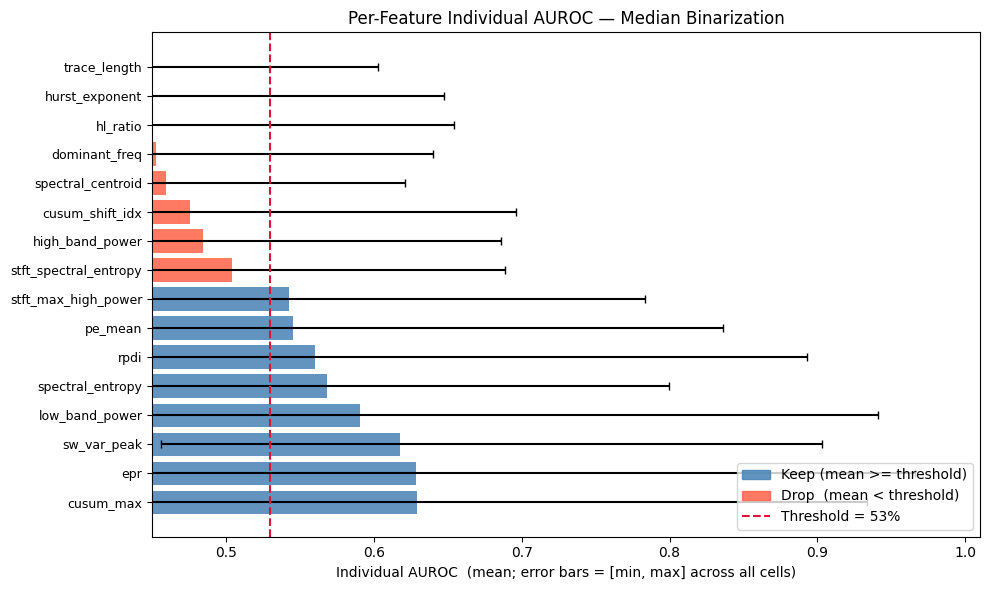


Feature                       Mean      Min      Max  Status
------------------------------------------------------------
cusum_max                    0.629    0.402    0.934  KEEP
epr                          0.629    0.444    0.966  KEEP
sw_var_peak                  0.618    0.456    0.903  KEEP
low_band_power               0.591    0.296    0.941  KEEP
spectral_entropy             0.568    0.100    0.799  KEEP
rpdi                         0.560    0.327    0.893  KEEP
pe_mean                      0.545    0.250    0.836  KEEP
stft_max_high_power          0.542    0.170    0.783  KEEP
stft_spectral_entropy        0.504    0.079    0.689  DROP
high_band_power              0.484    0.059    0.686  DROP
cusum_shift_idx              0.476    0.155    0.696  DROP
spectral_centroid            0.459    0.057    0.621  DROP
dominant_freq                0.453    0.061    0.640  DROP
hl_ratio                     0.445    0.040    0.654  DROP
hurst_exponent               0.438    0.082    0.64

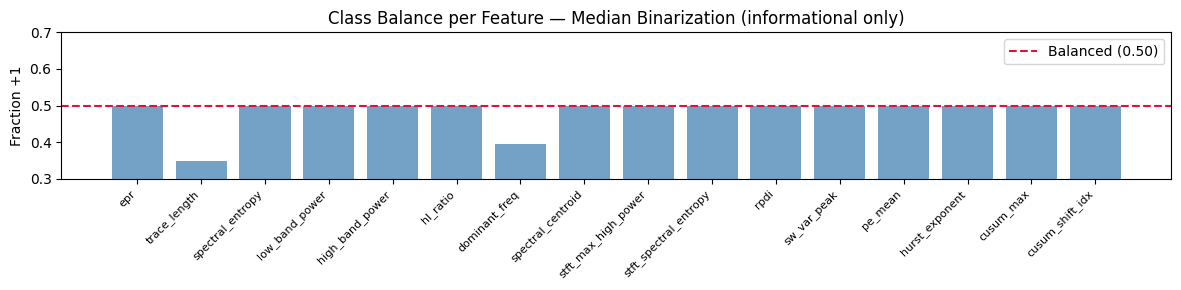


GOOD_FEATURES_MEDIAN (8/16): ['epr', 'spectral_entropy', 'low_band_power', 'stft_max_high_power', 'rpdi', 'sw_var_peak', 'pe_mean', 'cusum_max']
Dropped (8):          ['trace_length', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_spectral_entropy', 'hurst_exponent', 'cusum_shift_idx']

Tip: adjust MIN_IND_AUC_THRESHOLD in Cell 2 and re-run if the split looks off.
GOOD_FEATURES_OPT will be derived in Cell 6 after quantile optimisation.


In [17]:
# Cell 4: Feature AUROC diagnostic — median binarization → GOOD_FEATURES_MEDIAN
print(f'Computing individual AUROCs (median binarization) for {len(FEAT_NAMES)} features across {len(ALL_CELLS)} cells...')
per_feat_aucs = {fn: [] for fn in FEAT_NAMES}

for cell_key, (fd, lbl) in ALL_CELLS.items():
    if len(set(lbl.tolist())) < 2:
        continue
    for fn in FEAT_NAMES:
        if fn not in fd:
            continue
        try:
            sign = FEATURE_SIGNS.get(fn, +1)
            a, *_ = boot_auc(lbl, np.array(fd[fn], dtype=float) * sign)
            if not np.isnan(a):
                per_feat_aucs[fn].append(float(a))
        except Exception:
            pass

mean_aucs, min_aucs, max_aucs = {}, {}, {}
for fn in FEAT_NAMES:
    aucs = per_feat_aucs[fn]
    mean_aucs[fn] = float(np.mean(aucs))  if aucs else float('nan')
    min_aucs[fn]  = float(np.min(aucs))   if aucs else float('nan')
    max_aucs[fn]  = float(np.max(aucs))   if aucs else float('nan')

sorted_feats = sorted(FEAT_NAMES, key=lambda fn: mean_aucs.get(fn, 0.0), reverse=True)

# Plot 1: Horizontal bar chart sorted by mean AUROC with [min, max] error bars
fig, ax = plt.subplots(figsize=(10, 6))
y_pos  = np.arange(len(sorted_feats))
means  = [mean_aucs[fn] for fn in sorted_feats]
lows   = [mean_aucs[fn] - min_aucs[fn] for fn in sorted_feats]
highs  = [max_aucs[fn]  - mean_aucs[fn] for fn in sorted_feats]
colors = ['tomato' if mean_aucs[fn] < MIN_IND_AUC_THRESHOLD else 'steelblue'
          for fn in sorted_feats]
ax.barh(y_pos, means, xerr=[lows, highs], capsize=3, color=colors, alpha=0.85)
ax.axvline(MIN_IND_AUC_THRESHOLD, color='crimson', linestyle='--', lw=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_feats, fontsize=9)
ax.set_xlabel('Individual AUROC  (mean; error bars = [min, max] across all cells)')
ax.set_title('Per-Feature Individual AUROC — Median Binarization')
keep_p = mpatches.Patch(color='steelblue', alpha=0.85, label='Keep (mean >= threshold)')
drop_p = mpatches.Patch(color='tomato',    alpha=0.85, label='Drop  (mean < threshold)')
thr_l  = plt.Line2D([0],[0], color='crimson', linestyle='--', lw=1.5,
                    label=f'Threshold = {MIN_IND_AUC_THRESHOLD:.0%}')
ax.legend(handles=[keep_p, drop_p, thr_l], loc='lower right')
ax.set_xlim(0.45, 1.01)
plt.tight_layout()
plt.show()

print()
print(f'{"Feature":<25} {"Mean":>8} {"Min":>8} {"Max":>8}  Status')
print('-' * 60)
for fn in sorted_feats:
    status = 'KEEP' if mean_aucs.get(fn, 0) >= MIN_IND_AUC_THRESHOLD else 'DROP'
    print(f'{fn:<25} {mean_aucs[fn]:>8.3f} {min_aucs[fn]:>8.3f} {max_aucs[fn]:>8.3f}  {status}')

# ─── Part B: Class balance after median binarization (informational) ──────────
frac_pos_median = {}
sample_items = list(ALL_CELLS.items())[:min(10, len(ALL_CELLS))]
for fn in FEAT_NAMES:
    fracs = []
    for _, (fd, _) in sample_items:
        if fn not in fd: continue
        oriented = np.array(fd[fn], dtype=float) * FEATURE_SIGNS.get(fn, +1)
        b = np.where(oriented > np.median(oriented), 1.0, -1.0)
        fracs.append(float((b == 1.0).mean()))
    frac_pos_median[fn] = float(np.mean(fracs)) if fracs else 0.5

fig2, ax2 = plt.subplots(figsize=(12, 3))
x_pos = np.arange(len(FEAT_NAMES))
ax2.bar(x_pos, [frac_pos_median[fn] for fn in FEAT_NAMES], color='steelblue', alpha=0.75)
ax2.axhline(0.50, color='crimson', linestyle='--', lw=1.5, label='Balanced (0.50)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Fraction +1')
ax2.set_title('Class Balance per Feature — Median Binarization (informational only)')
ax2.set_ylim(0.3, 0.7)
ax2.legend()
plt.tight_layout()
plt.show()

# ─── Define GOOD_FEATURES_MEDIAN based on threshold ──────────────────────────
GOOD_FEATURES_MEDIAN = [fn for fn in FEAT_NAMES if mean_aucs.get(fn, 0) >= MIN_IND_AUC_THRESHOLD]
dropped_median       = [fn for fn in FEAT_NAMES if fn not in GOOD_FEATURES_MEDIAN]
print(f'\nGOOD_FEATURES_MEDIAN ({len(GOOD_FEATURES_MEDIAN)}/16): {GOOD_FEATURES_MEDIAN}')
print(f'Dropped ({len(dropped_median)}):          {dropped_median}')
print()
print('Tip: adjust MIN_IND_AUC_THRESHOLD in Cell 2 and re-run if the split looks off.')
print('GOOD_FEATURES_OPT will be derived in Cell 6 after quantile optimisation.')

## Section 5 — Per-Feature Quantile Optimisation

Loaded quantile optimisation from /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_opt_quantiles.pkl


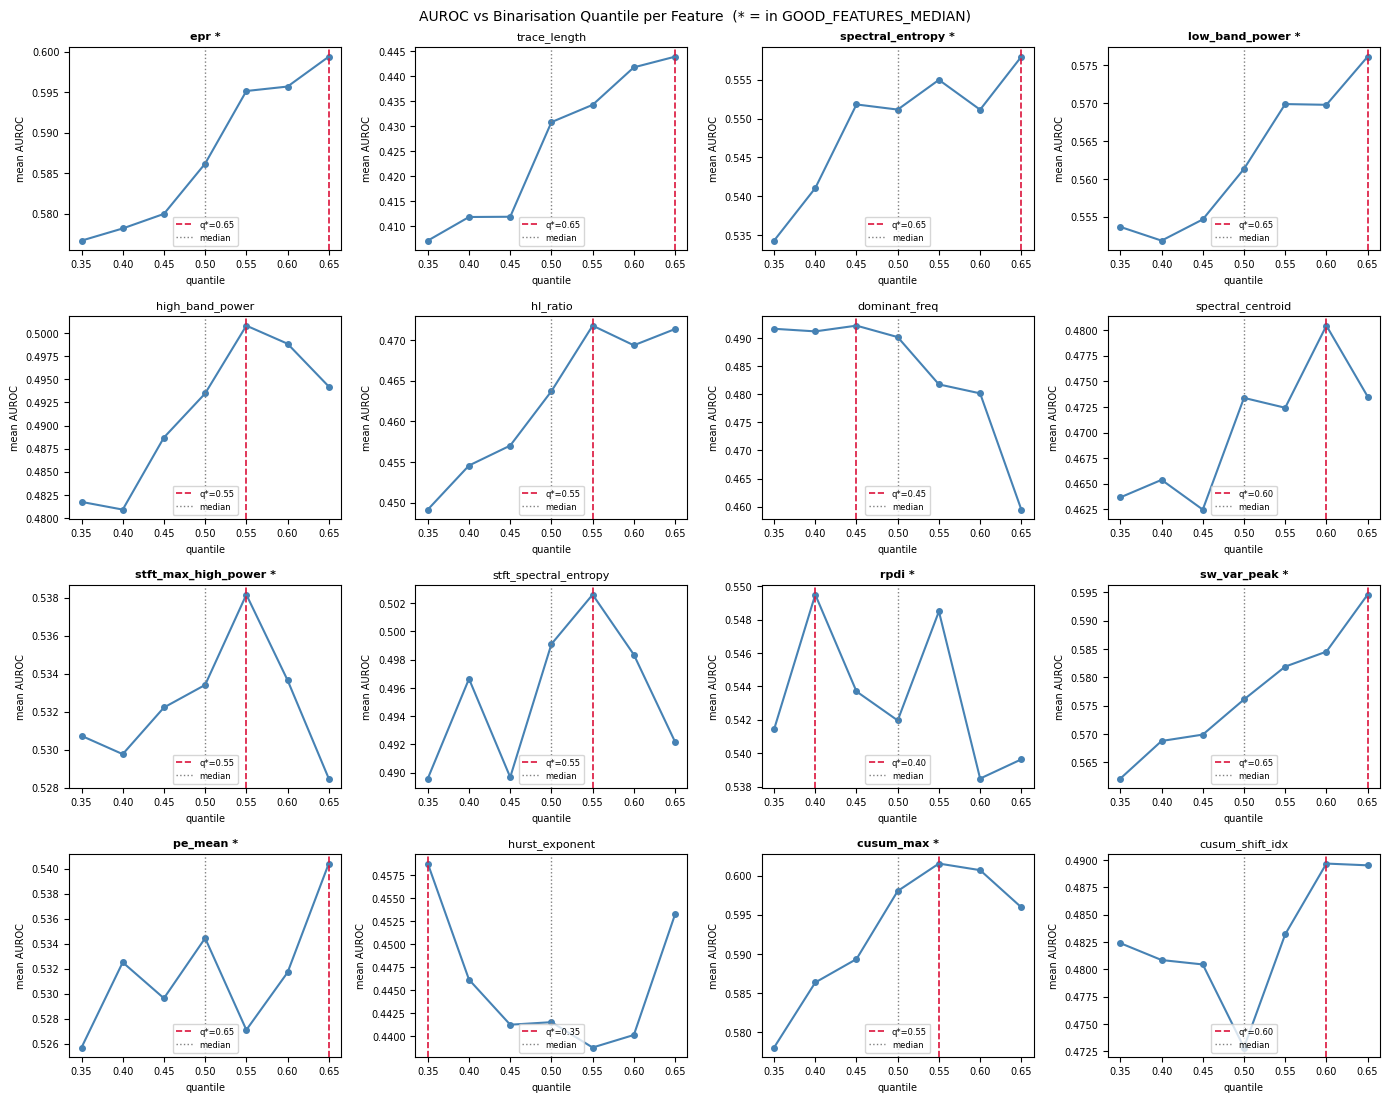


FEATURE_QUANTILES_ALL (all 16):
{'epr': 0.65, 'trace_length': 0.65, 'spectral_entropy': 0.65, 'low_band_power': 0.65, 'high_band_power': 0.55, 'hl_ratio': 0.55, 'dominant_freq': 0.45, 'spectral_centroid': 0.6, 'stft_max_high_power': 0.55, 'stft_spectral_entropy': 0.55, 'rpdi': 0.4, 'sw_var_peak': 0.65, 'pe_mean': 0.65, 'hurst_exponent': 0.35, 'cusum_max': 0.55, 'cusum_shift_idx': 0.6}


In [18]:
# Cell 5: Per-feature quantile optimisation (offline, one-time, saved to Drive)
QUANT_OPT_PATH  = os.path.join(OUT_DIR, 'lsml_opt_quantiles.pkl')
FORCE_QUANT_OPT = False

if not FORCE_QUANT_OPT and os.path.exists(QUANT_OPT_PATH):
    with open(QUANT_OPT_PATH, 'rb') as f:
        _saved = pickle.load(f)
    FEATURE_QUANTILES_ALL = _saved['quantiles']
    quant_auc_curves      = _saved.get('curves', {})
    print(f'Loaded quantile optimisation from {QUANT_OPT_PATH}')
else:
    print(f'Quantile grid search: {len(QUANTILE_GRID)} values x '
          f'{len(FEAT_NAMES)} features x {len(ALL_CELLS)} cells ...')
    FEATURE_QUANTILES_ALL = {}
    quant_auc_curves = {}

    for fn in FEAT_NAMES:
        sign   = FEATURE_SIGNS.get(fn, +1)
        q_aucs = []
        for q in QUANTILE_GRID:
            cell_aucs = []
            for cell_key, (fd, lbl) in ALL_CELLS.items():
                if fn not in fd or len(set(lbl.tolist())) < 2:
                    continue
                oriented = np.array(fd[fn], dtype=float) * sign
                thr      = np.quantile(oriented, q)
                binary   = np.where(oriented > thr, 1.0, -1.0)
                try:
                    a, *_ = boot_auc(lbl, binary)
                    if not np.isnan(a):
                        cell_aucs.append(float(a))
                except Exception:
                    pass
            q_aucs.append(float(np.mean(cell_aucs)) if cell_aucs else 0.5)
        quant_auc_curves[fn] = q_aucs
        best_idx = int(np.argmax(q_aucs))
        med_idx  = len(QUANTILE_GRID) // 2
        FEATURE_QUANTILES_ALL[fn] = float(QUANTILE_GRID[best_idx])
        delta = q_aucs[best_idx] - q_aucs[med_idx]
        print(f'  {fn:<25} q*={FEATURE_QUANTILES_ALL[fn]:.2f}  '
              f'AUC@q*={q_aucs[best_idx]:.3f}  AUC@median={q_aucs[med_idx]:.3f}  '
              f'delta={delta:+.3f}')

    with open(QUANT_OPT_PATH, 'wb') as f:
        pickle.dump({'quantiles': FEATURE_QUANTILES_ALL, 'curves': quant_auc_curves}, f)
    print(f'\nSaved -> {QUANT_OPT_PATH}')

# Plot 3: AUROC vs quantile curves (one panel per feature)
if quant_auc_curves:
    ncols = 4
    nrows = (len(FEAT_NAMES) + ncols - 1) // ncols
    fig3, axes3 = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.8))
    axes3_flat = axes3.flatten()
    for i, fn in enumerate(FEAT_NAMES):
        ax = axes3_flat[i]
        if fn in quant_auc_curves:
            ax.plot(QUANTILE_GRID, quant_auc_curves[fn], 'o-', ms=4, color='steelblue')
            ax.axvline(FEATURE_QUANTILES_ALL[fn], color='crimson', linestyle='--', lw=1.2,
                       label=f'q*={FEATURE_QUANTILES_ALL[fn]:.2f}')
            ax.axvline(0.50, color='gray', linestyle=':', lw=1, label='median')
            ax.legend(fontsize=6, loc='lower center')
        in_good = fn in GOOD_FEATURES_MEDIAN
        ax.set_title(f'{fn}{" *" if in_good else ""}', fontsize=8,
                     fontweight='bold' if in_good else 'normal')
        ax.set_xlabel('quantile', fontsize=7)
        ax.set_ylabel('mean AUROC', fontsize=7)
        ax.tick_params(labelsize=7)
    for j in range(len(FEAT_NAMES), len(axes3_flat)):
        axes3_flat[j].set_visible(False)
    fig3.suptitle('AUROC vs Binarisation Quantile per Feature  (* = in GOOD_FEATURES_MEDIAN)',
                  fontsize=10)
    plt.tight_layout()
    plt.show()

print('\nFEATURE_QUANTILES_ALL (all 16):')
print(repr({k: round(v, 2) for k, v in FEATURE_QUANTILES_ALL.items()}))

## Section 6 — Class Balance + Individual AUROC (Optimised) → GOOD_FEATURES_OPT

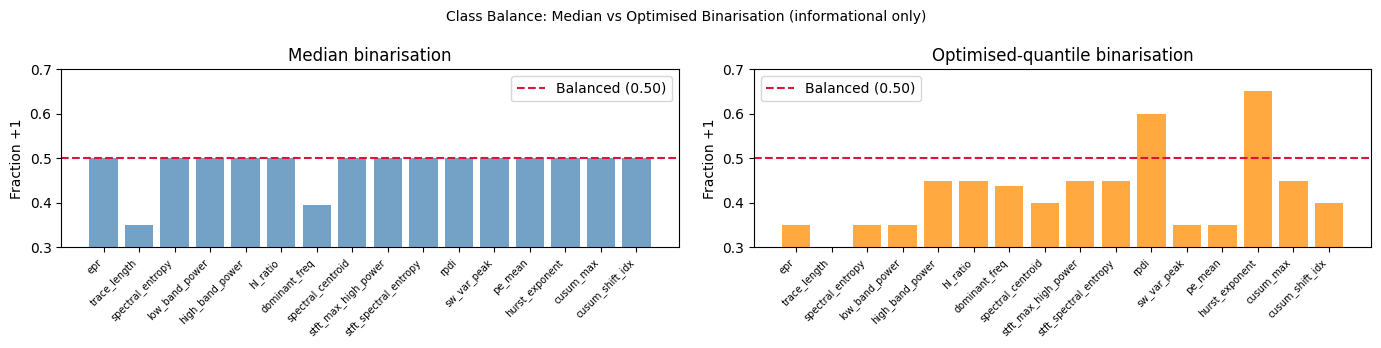

Feature                    Median frac+1   Opt frac+1     Shift
-----------------------------------------------------------------
epr                                0.500        0.349    -0.151
trace_length                       0.350        0.244    -0.106
spectral_entropy                   0.500        0.349    -0.151
low_band_power                     0.500        0.349    -0.151
high_band_power                    0.500        0.450    -0.050
hl_ratio                           0.500        0.450    -0.050
dominant_freq                      0.395        0.438    +0.042
spectral_centroid                  0.500        0.400    -0.100
stft_max_high_power                0.500        0.450    -0.050
stft_spectral_entropy              0.500        0.450    -0.050
rpdi                               0.500        0.600    +0.101
sw_var_peak                        0.500        0.349    -0.151
pe_mean                            0.500        0.349    -0.151
hurst_exponent                     0.5

In [19]:
# Cell 6: Class balance plots + derive GOOD_FEATURES_OPT from optimised-quantile AUROCs

# ─── Part A: Balance plots (median vs optimised) ──────────────────────────────
frac_pos_opt = {}
sample_items = list(ALL_CELLS.items())[:min(10, len(ALL_CELLS))]
for fn in FEAT_NAMES:
    fracs = []
    for _, (fd, _) in sample_items:
        if fn not in fd: continue
        oriented = np.array(fd[fn], dtype=float) * FEATURE_SIGNS.get(fn, +1)
        q   = FEATURE_QUANTILES_ALL.get(fn, 0.5)
        thr = np.quantile(oriented, q)
        b   = np.where(oriented > thr, 1.0, -1.0)
        fracs.append(float((b == 1.0).mean()))
    frac_pos_opt[fn] = float(np.mean(fracs)) if fracs else 0.5

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 3.5))
x_pos = np.arange(len(FEAT_NAMES))
for ax4, fracs_dict, title, col in [
        (axes4[0], frac_pos_median, 'Median binarisation',           'steelblue'),
        (axes4[1], frac_pos_opt,    'Optimised-quantile binarisation', 'darkorange')]:
    ax4.bar(x_pos, [fracs_dict[fn] for fn in FEAT_NAMES], color=col, alpha=0.75)
    ax4.axhline(0.50, color='crimson', linestyle='--', lw=1.5, label='Balanced (0.50)')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=7)
    ax4.set_ylim(0.3, 0.7)
    ax4.set_ylabel('Fraction +1')
    ax4.set_title(title)
    ax4.legend()
fig4.suptitle('Class Balance: Median vs Optimised Binarisation (informational only)', fontsize=10)
plt.tight_layout()
plt.show()

print(f'{"Feature":<25} {"Median frac+1":>14} {"Opt frac+1":>12}  {"Shift":>8}')
print('-' * 65)
for fn in FEAT_NAMES:
    shift = frac_pos_opt[fn] - frac_pos_median[fn]
    print(f'{fn:<25} {frac_pos_median[fn]:>14.3f} {frac_pos_opt[fn]:>12.3f}  {shift:>+8.3f}')

# ─── Part B: Individual AUROCs at optimised quantile → GOOD_FEATURES_OPT ─────
print('\nComputing individual AUROCs at optimised-quantile binarization ...')
per_feat_aucs_opt = {fn: [] for fn in FEAT_NAMES}
for cell_key, (fd, lbl) in ALL_CELLS.items():
    if len(set(lbl.tolist())) < 2:
        continue
    for fn in FEAT_NAMES:
        if fn not in fd:
            continue
        try:
            sign     = FEATURE_SIGNS.get(fn, +1)
            oriented = np.array(fd[fn], dtype=float) * sign
            q        = FEATURE_QUANTILES_ALL.get(fn, 0.5)
            thr      = np.quantile(oriented, q)
            binary   = np.where(oriented > thr, 1.0, -1.0)
            a, *_ = boot_auc(lbl, binary)
            if not np.isnan(a):
                per_feat_aucs_opt[fn].append(float(a))
        except Exception:
            pass

mean_aucs_opt = {fn: float(np.mean(v)) if v else float('nan')
                 for fn, v in per_feat_aucs_opt.items()}

GOOD_FEATURES_OPT    = [fn for fn in FEAT_NAMES if mean_aucs_opt.get(fn, 0) >= MIN_IND_AUC_THRESHOLD]
FEATURE_QUANTILES_OPT = {fn: FEATURE_QUANTILES_ALL[fn] for fn in GOOD_FEATURES_OPT}

sorted_by_opt = sorted(FEAT_NAMES, key=lambda fn: mean_aucs_opt.get(fn, 0), reverse=True)
print(f'\n{"Feature":<25} {"Med AUROC":>10} {"Opt AUROC":>10}  {"Med subset":>11}  {"Opt subset":>10}')
print('-' * 73)
for fn in sorted_by_opt:
    med_status = 'KEEP' if fn in GOOD_FEATURES_MEDIAN else 'drop'
    opt_status = 'KEEP' if fn in GOOD_FEATURES_OPT    else 'drop'
    print(f'{fn:<25} {mean_aucs[fn]:>10.3f} {mean_aucs_opt[fn]:>10.3f}  {med_status:>11}  {opt_status:>10}')

print(f'\nGOOD_FEATURES_MEDIAN ({len(GOOD_FEATURES_MEDIAN)}/16): {GOOD_FEATURES_MEDIAN}')
print(f'GOOD_FEATURES_OPT    ({len(GOOD_FEATURES_OPT)}/16): {GOOD_FEATURES_OPT}')
print(f'FEATURE_QUANTILES_OPT: {repr({k: round(v,2) for k, v in FEATURE_QUANTILES_OPT.items()})}')
print('\nTip: if both subsets are identical, either threshold is too coarse or features cluster tightly.')

## Section 7 — Run 2×2 Ablation

In [20]:
# Cell 7: 2x2 ablation — run all four variants across every cell
# NOTE: if you changed MIN_IND_AUC_THRESHOLD or FEATURE_QUANTILES_ALL, set FORCE_VARIANTS = True
# to discard cached results and recompute with the new subsets.
OPT_RES_PATH   = os.path.join(OUT_DIR, 'lsml_optimized_results_all.pkl')
FORCE_VARIANTS = True

if not FORCE_VARIANTS and os.path.exists(OPT_RES_PATH):
    with open(OPT_RES_PATH, 'rb') as f:
        variant_results = pickle.load(f)
    print(f'Loaded {len(variant_results)} cached results from {OPT_RES_PATH}')
    remaining = {k: v for k, v in ALL_CELLS.items() if k not in variant_results}
else:
    variant_results = {}
    remaining = dict(ALL_CELLS)

print(f'{len(remaining)} cells to compute ...')

# Union of both subsets for best_ind_auc denominator
_all_good = set(GOOD_FEATURES_MEDIAN) | set(GOOD_FEATURES_OPT)

for cell_key, (fd, lbl) in remaining.items():
    if len(set(lbl.tolist())) < 2:
        continue

    # Best individual AUROC among the union of both subsets
    best_ind = 0.0
    for fn in _all_good:
        if fn not in fd: continue
        try:
            sign = FEATURE_SIGNS.get(fn, +1)
            a, *_ = boot_auc(lbl, np.array(fd[fn], dtype=float) * sign)
            if not np.isnan(a): best_ind = max(best_ind, float(a))
        except Exception: pass

    rec = {'best_ind_auc': best_ind}

    def _fuse(binary_dict, tag):
        if len(binary_dict) < 3:
            return None
        try:
            fused, _ = lsml_fuse(*binary_dict.values())
            p_auc, p_lo, p_hi = boot_auc(lbl,  fused)
            n_auc, n_lo, n_hi = boot_auc(lbl, -fused)
            if p_auc >= n_auc:
                return (float(p_auc), float(p_lo), float(p_hi))
            return (float(n_auc), float(n_lo), float(n_hi))
        except Exception as e:
            print(f'  [{cell_key}] {tag} error: {e}')
            return None

    # V1: all-16, median (current v2 reference)
    b_all_med  = binarize_classifiers(fd, FEATURE_SIGNS)
    rec['v1_all_median'] = _fuse(b_all_med, 'V1')

    # V2: GOOD_FEATURES_MEDIAN subset, median binarization
    b_filt_med = {fn: b_all_med[fn] for fn in GOOD_FEATURES_MEDIAN if fn in b_all_med}
    rec['v2_filtered_median'] = _fuse(b_filt_med, 'V2')

    # V3: all-16, optimised quantile
    b_all_opt  = binarize_classifiers(fd, FEATURE_SIGNS, quantiles=FEATURE_QUANTILES_ALL)
    rec['v3_all_optimized'] = _fuse(b_all_opt, 'V3')

    # V4: GOOD_FEATURES_OPT subset, optimised quantile (each variant uses its own subset)
    b_filt_opt = {fn: b_all_opt[fn] for fn in GOOD_FEATURES_OPT if fn in b_all_opt}
    rec['v4_filtered_optimized'] = _fuse(b_filt_opt, 'V4')

    variant_results[cell_key] = rec
    # Incremental save after every cell
    with open(OPT_RES_PATH, 'wb') as f:
        pickle.dump(variant_results, f)

print(f'\nDone. {len(variant_results)} cells in {OPT_RES_PATH}')

valid = {k: v for k, v in variant_results.items() if v and v.get('v1_all_median')}
v1_mean = float(np.mean([v['v1_all_median'][0] for v in valid.values()]))
v4_vals = [v['v4_filtered_optimized'][0] for v in valid.values() if v.get('v4_filtered_optimized')]
v4_mean = float(np.mean(v4_vals)) if v4_vals else float('nan')
print(f'V1 mean AUROC: {v1_mean:.3f}')
print(f'V4 mean AUROC: {v4_mean:.3f}  (combined delta = {v4_mean - v1_mean:+.3f})')

30 cells to compute ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:372: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  _, diffusion_map = eigsh(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:372: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  _, diffusion_map = eigsh(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:372: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  _, diffusion_map = eigsh(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:372: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  _, diffusion_map = eigsh(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:372: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead


Done. 29 cells in /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_optimized_results_all.pkl
V1 mean AUROC: 0.616
V4 mean AUROC: 0.650  (combined delta = +0.034)


## Section 8 — Fusion Lift Visualisation

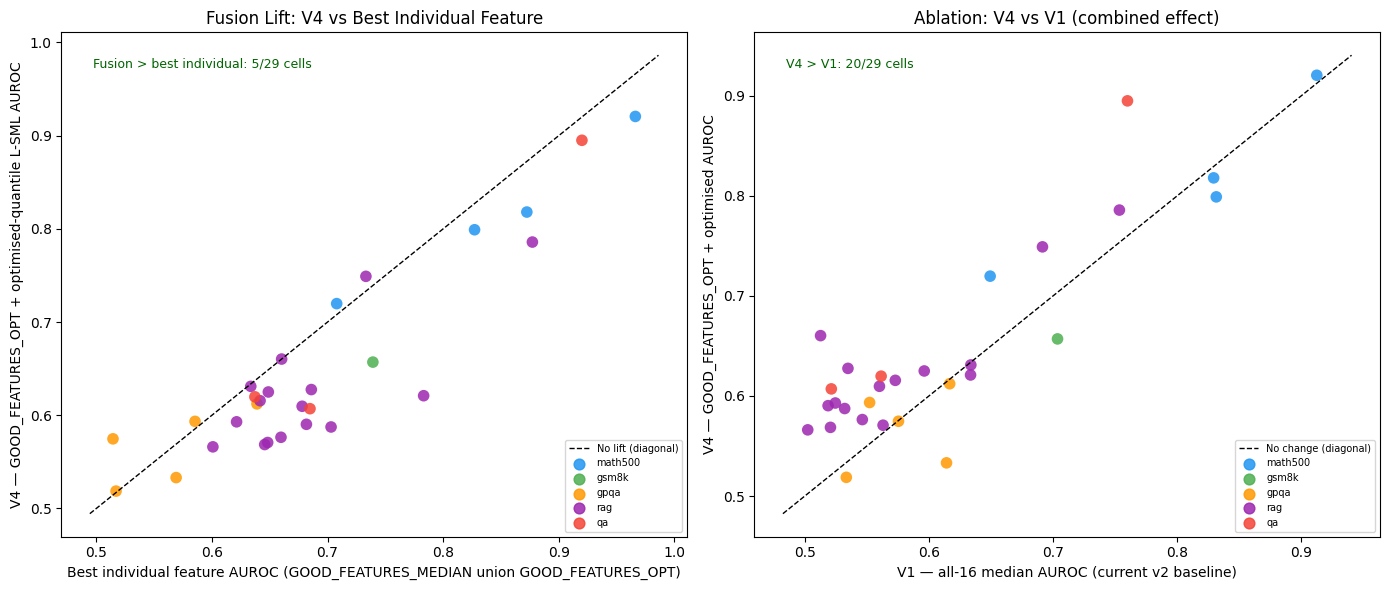


Variant                        Mean AUROC    vs V1  N cells
------------------------------------------------------------
V1 all-16 median                    0.616   +0.000       29
V2 filtered median                  0.626   +0.010       29
V3 all-16 optimized                 0.618   +0.002       29
V4 filtered optimized               0.650   +0.034       29

Effect decomposition (N=29 cells with all 4 variants):
  Subset effect   (median binarisation):    V1->V2  +0.010
  Threshold effect (all features):          V1->V3  +0.002
  Subset effect   (opt binarisation):       V3->V4  +0.032
  Threshold effect (filtered features):     V2->V4  +0.024
  Combined effect:                          V1->V4  +0.034


In [21]:
# Cell 8: Fusion lift visualisation
valid = {k: v for k, v in variant_results.items()
         if v and v.get('v4_filtered_optimized') and v.get('best_ind_auc', 0) > 0}

cell_keys = list(valid.keys())
best_inds  = [valid[k]['best_ind_auc'] for k in cell_keys]
v4_aucs    = [valid[k]['v4_filtered_optimized'][0] for k in cell_keys]
v1_aucs    = [valid[k]['v1_all_median'][0] for k in cell_keys if valid[k].get('v1_all_median')]

domain_colors = {'math500': '#2196F3', 'gsm8k': '#4CAF50', 'gpqa': '#FF9800',
                 'rag': '#9C27B0', 'qa': '#F44336'}
pt_colors = [domain_colors.get(k.split('/')[0], 'gray') for k in cell_keys]

fig5, axes5 = plt.subplots(1, 2, figsize=(14, 6))

# Left: V4 vs best individual feature (union of both subsets)
ax_l = axes5[0]
lo = min(min(best_inds), min(v4_aucs)) - 0.02
hi = max(max(best_inds), max(v4_aucs)) + 0.02
ax_l.plot([lo, hi], [lo, hi], 'k--', lw=1, label='No lift (diagonal)')
ax_l.scatter(best_inds, v4_aucs, c=pt_colors, alpha=0.85, s=70, edgecolors='none')
for dom, col in domain_colors.items():
    ax_l.scatter([], [], c=col, alpha=0.85, s=60, label=dom)
n_above_ind = sum(v4 > bi for v4, bi in zip(v4_aucs, best_inds))
ax_l.text(0.05, 0.95, f'Fusion > best individual: {n_above_ind}/{len(v4_aucs)} cells',
          transform=ax_l.transAxes, va='top', fontsize=9, color='darkgreen')
ax_l.set_xlabel('Best individual feature AUROC (GOOD_FEATURES_MEDIAN union GOOD_FEATURES_OPT)')
ax_l.set_ylabel('V4 — GOOD_FEATURES_OPT + optimised-quantile L-SML AUROC')
ax_l.set_title('Fusion Lift: V4 vs Best Individual Feature')
ax_l.legend(fontsize=7)

# Right: V4 vs V1 (combined effect of both changes)
ax_r = axes5[1]
lo2 = min(min(v1_aucs), min(v4_aucs[:len(v1_aucs)])) - 0.02
hi2 = max(max(v1_aucs), max(v4_aucs[:len(v1_aucs)])) + 0.02
ax_r.plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, label='No change (diagonal)')
ax_r.scatter(v1_aucs, v4_aucs[:len(v1_aucs)],
             c=pt_colors[:len(v1_aucs)], alpha=0.85, s=70, edgecolors='none')
for dom, col in domain_colors.items():
    ax_r.scatter([], [], c=col, alpha=0.85, s=60, label=dom)
n_above_v1 = sum(v4 > v1 for v4, v1 in zip(v4_aucs[:len(v1_aucs)], v1_aucs))
ax_r.text(0.05, 0.95, f'V4 > V1: {n_above_v1}/{len(v1_aucs)} cells',
          transform=ax_r.transAxes, va='top', fontsize=9, color='darkgreen')
ax_r.set_xlabel('V1 — all-16 median AUROC (current v2 baseline)')
ax_r.set_ylabel('V4 — GOOD_FEATURES_OPT + optimised AUROC')
ax_r.set_title('Ablation: V4 vs V1 (combined effect)')
ax_r.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ─── Summary statistics ───────────────────────────────────────────────────────
variants_meta = [
    ('V1 all-16 median',      'v1_all_median'),
    ('V2 filtered median',    'v2_filtered_median'),
    ('V3 all-16 optimized',   'v3_all_optimized'),
    ('V4 filtered optimized', 'v4_filtered_optimized'),
]
v1_ref = float(np.mean([v['v1_all_median'][0] for v in valid.values()
                         if v.get('v1_all_median')]))
print(f'\n{"Variant":<28} {"Mean AUROC":>12} {"vs V1":>8} {"N cells":>8}')
print('-' * 60)
for label, key in variants_meta:
    vals = [v[key][0] for v in valid.values() if v.get(key)]
    if vals:
        m = float(np.mean(vals))
        print(f'{label:<28} {m:>12.3f} {m-v1_ref:>+8.3f} {len(vals):>8}')
    else:
        print(f'{label:<28} {"N/A":>12}')

# ─── Effect decomposition ─────────────────────────────────────────────────────
quad = {k: v for k, v in valid.items()
        if all(v.get(key) for _, key in variants_meta)}
if quad:
    V1 = float(np.mean([v['v1_all_median'][0]          for v in quad.values()]))
    V2 = float(np.mean([v['v2_filtered_median'][0]     for v in quad.values()]))
    V3 = float(np.mean([v['v3_all_optimized'][0]       for v in quad.values()]))
    V4 = float(np.mean([v['v4_filtered_optimized'][0]  for v in quad.values()]))
    print(f'\nEffect decomposition (N={len(quad)} cells with all 4 variants):')
    print(f'  Subset effect   (median binarisation):    V1->V2  {V2-V1:+.3f}')
    print(f'  Threshold effect (all features):          V1->V3  {V3-V1:+.3f}')
    print(f'  Subset effect   (opt binarisation):       V3->V4  {V4-V3:+.3f}')
    print(f'  Threshold effect (filtered features):     V2->V4  {V4-V2:+.3f}')
    print(f'  Combined effect:                          V1->V4  {V4-V1:+.3f}')

## Section 9 — Summary Table & Save

In [22]:
# Cell 9: Full comparison table + save to Drive
import pandas as pd

variants_meta = [
    ('V1 all-16 median',      'v1_all_median'),
    ('V2 filtered median',    'v2_filtered_median'),
    ('V3 all-16 optimized',   'v3_all_optimized'),
    ('V4 filtered optimized', 'v4_filtered_optimized'),
]

rows = []
for cell_key, rec in sorted(variant_results.items()):
    if not rec: continue
    row = {'cell': cell_key,
           'best_ind_auc': round(float(rec.get('best_ind_auc', float('nan'))), 4)}
    for label, key in variants_meta:
        short = label.split()[0].lower()
        if rec.get(key):
            auc, lo, hi = rec[key]
            row[f'{short}_auc'] = round(float(auc), 4)
            row[f'{short}_ci']  = f'[{lo:.3f},{hi:.3f}]'
        else:
            row[f'{short}_auc'] = float('nan')
            row[f'{short}_ci']  = 'N/A'
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = os.path.join(OUT_DIR, 'lsml_optimized_summary.csv')
df.to_csv(csv_path, index=False)
print(f'Saved CSV -> {csv_path}')

# Print table
hdr = f'{"Cell":<45} {"BestInd":>8} {"V1":>8} {"V2":>8} {"V3":>8} {"V4":>8}'
print(); print('=' * len(hdr)); print(hdr); print('=' * len(hdr))
for _, row in df.iterrows():
    print(f'{str(row["cell"]):<45} '
          f'{row["best_ind_auc"]:>8.3f} '
          f'{row["v1_auc"]:>8.3f} '
          f'{row["v2_auc"]:>8.3f} '
          f'{row["v3_auc"]:>8.3f} '
          f'{row["v4_auc"]:>8.3f}')
print('=' * len(hdr))

print(f'\nFiles saved to Drive:')
print(f'  {OPT_RES_PATH}')
print(f'  {csv_path}')
print(f'  {QUANT_OPT_PATH}')
print(f'\nTo adopt V4 in Phase 13/14 — add to Cell 2 config:')
print('GOOD_FEATURES_OPT =', repr(GOOD_FEATURES_OPT))
print('FEATURE_QUANTILES_OPT =', repr({k: round(v, 2) for k, v in FEATURE_QUANTILES_OPT.items()}))

Saved CSV -> /content/drive/MyDrive/hallucination_detection/consolidated_results/lsml_optimized_summary.csv

Cell                                           BestInd       V1       V2       V3       V4
gpqa/DeepSeek-R1-Distill-Llama-8B_T1.0           0.585    0.552    0.573    0.551    0.594
gpqa/Llama-8B_T1.0                               0.517    0.533    0.512    0.546    0.519
gpqa/Mistral-7B_T1.0                             0.514    0.576    0.561    0.577    0.575
gpqa/Qwen-7B_T1.0                                0.569    0.614    0.500    0.559    0.533
gpqa/Qwen2.5-72B-Instruct-AWQ_T1.0               0.639    0.617    0.612    0.620    0.612
gsm8k/Llama-8B_T1.0                              0.739    0.704    0.671    0.653    0.657
math500/DeepSeek-R1-Distill-Llama-8B_T1.0        0.827    0.832    0.833    0.794    0.799
math500/Qwen-Math-7B_T1.0                        0.966    0.913    0.920    0.935    0.921
math500/Qwen2.5-Math-1.5B-Instruct_T1.0          0.872    0.829    0.831

## Done

**Files saved to Drive `consolidated_results/`:**
- `lsml_opt_quantiles.pkl` — `{'quantiles': FEATURE_QUANTILES_ALL, 'curves': quant_auc_curves}`
- `lsml_optimized_results_all.pkl` — per-cell dict with v1/v2/v3/v4 AUROCs
- `lsml_optimized_summary.csv` — wide-format table (all variants side by side)

**2×2 ablation design (each variant uses its own subset):**

| | Median binarization | Optimized-quantile binarization |
|---|---|---|
| **All 16 features** | V1 (v2 reference) | V3 |
| **Filtered subset** | V2 (GOOD_FEATURES_MEDIAN) | **V4 (GOOD_FEATURES_OPT)** |

Reading off:
- **Subset effect** at fixed binarization: V1→V2 (median) and V3→V4 (optimized)
- **Threshold effect** at fixed feature set: V1→V3 (all-16) and V2→V4 (filtered)
- **Combined effect**: V1→V4

**To adopt V4 in Phase 13/14 notebooks**, copy the printed `GOOD_FEATURES_OPT` and
`FEATURE_QUANTILES_OPT` from Cell 9 into the Phase notebook's Cell 2 config, then change:
```python
# Before
binary = binarize_classifiers(fd, FEATURE_SIGNS)
fused, meta = lsml_fuse(*binary.values())

# After (V4)
binary = binarize_classifiers(fd, FEATURE_SIGNS, quantiles=FEATURE_QUANTILES_OPT)
binary_filtered = {fn: binary[fn] for fn in GOOD_FEATURES_OPT if fn in binary}
fused, meta = lsml_fuse(*binary_filtered.values())
```